In [92]:
import numpy as np # linear algebra
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set_style('whitegrid')
from sklearn.decomposition import PCA 
from sklearn.cluster import k_means, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [93]:
df = pd.read_csv(r'/kaggle/input/datasets/nelakurthisudheer/mall-customer-segmentation/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [94]:
print(f'DataFrame shape: {df.shape}')
print(f'DataFrame column types: \n{df.dtypes}\n')
print(f'DataFrame columns containing null values: {df.columns.isna().sum()}')

DataFrame shape: (200, 5)
DataFrame column types: 
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

DataFrame columns containing null values: 0


In [95]:
df[['Annual Income (k$)', 'Spending Score (1-100)']].describe(include=['int64'])

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


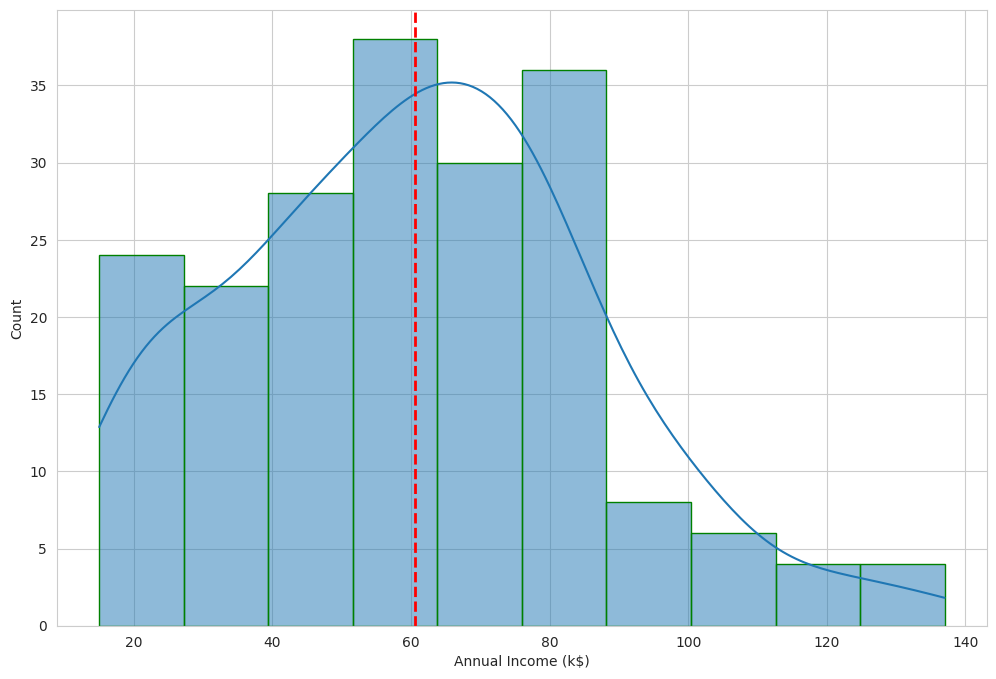

In [96]:
plt.figure(figsize=(12, 8))

sns.histplot(
    df['Annual Income (k$)'], 
    bins=10, 
    kde=True,
    edgecolor='green'
)
plt.axvline(
    np.mean(df['Annual Income (k$)']),
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Средний скор: { np.mean(df['Annual Income (k$)']):.1f}'
)
            
# help(sns.histplot)

In [97]:
# df['spending_per_score'] = np.round(df['Annual Income (k$)']/df['Spending Score (1-100)'], 2)
df['is_male'] = np.where(df['Gender'].str.contains('Male'), 1, 0)
df['is_older_than_30'] = np.where(df['Age'].gt(30), 1, 0)
df.drop(columns=['Gender','CustomerID'], inplace=True)

/tmp/ipykernel_55/3671027644.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df['Age'], df['Annual Income (k$)'], s=50, cmap='viridis')


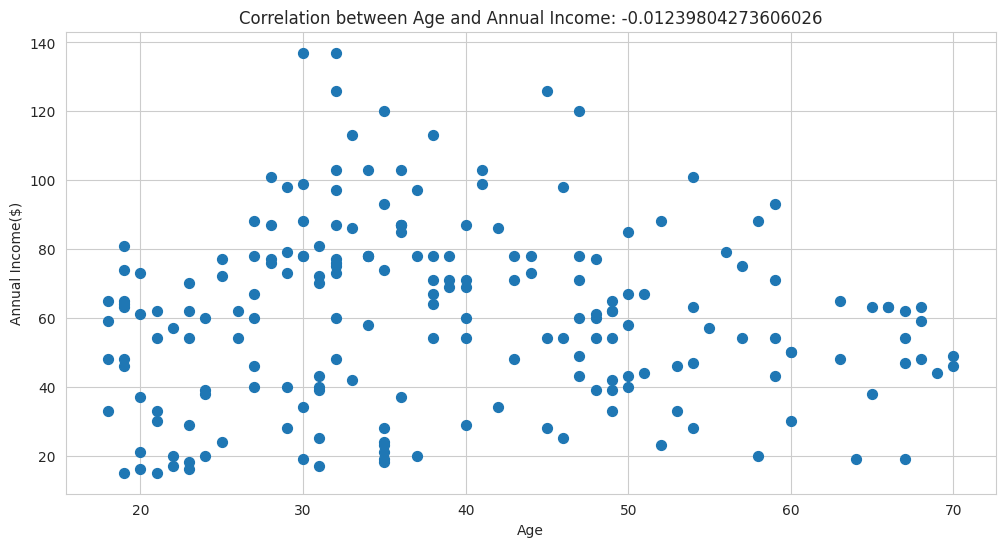

In [98]:
# Binning Ages 
# np.sort(df['Age'].unique())
plt.figure(figsize=(12, 6))

plt.scatter(df['Age'], df['Annual Income (k$)'], s=50, cmap='viridis')
plt.title(f'Correlation between Age and Annual Income: {(df[['Age', 'Annual Income (k$)']].corr()).iloc[0, 1]}')
plt.xlabel('Age')
plt.ylabel('Annual Income($)')
plt.show()

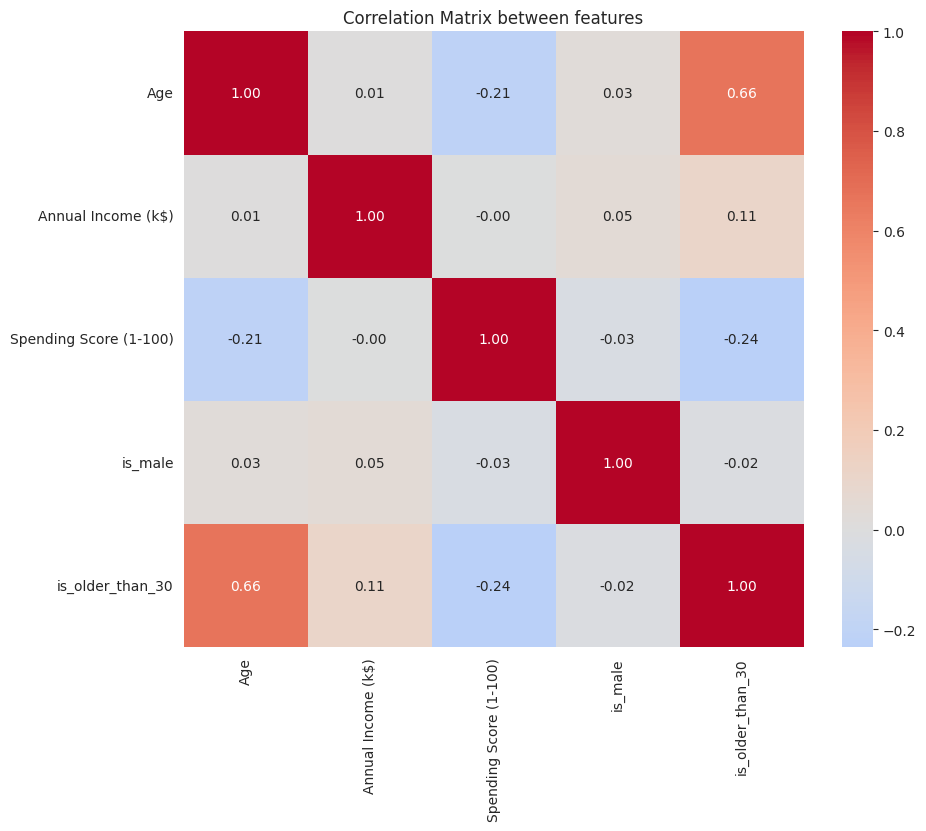

In [99]:
corr_matrix = df.corr('kendall')

plt.figure(figsize=(10, 8))


sns.heatmap(corr_matrix, 
            annot=True,      
            fmt=".2f",     
            cmap='coolwarm', 
            center=0)        

plt.title('Correlation Matrix between features')
plt.show()

<Figure size 1200x800 with 0 Axes>

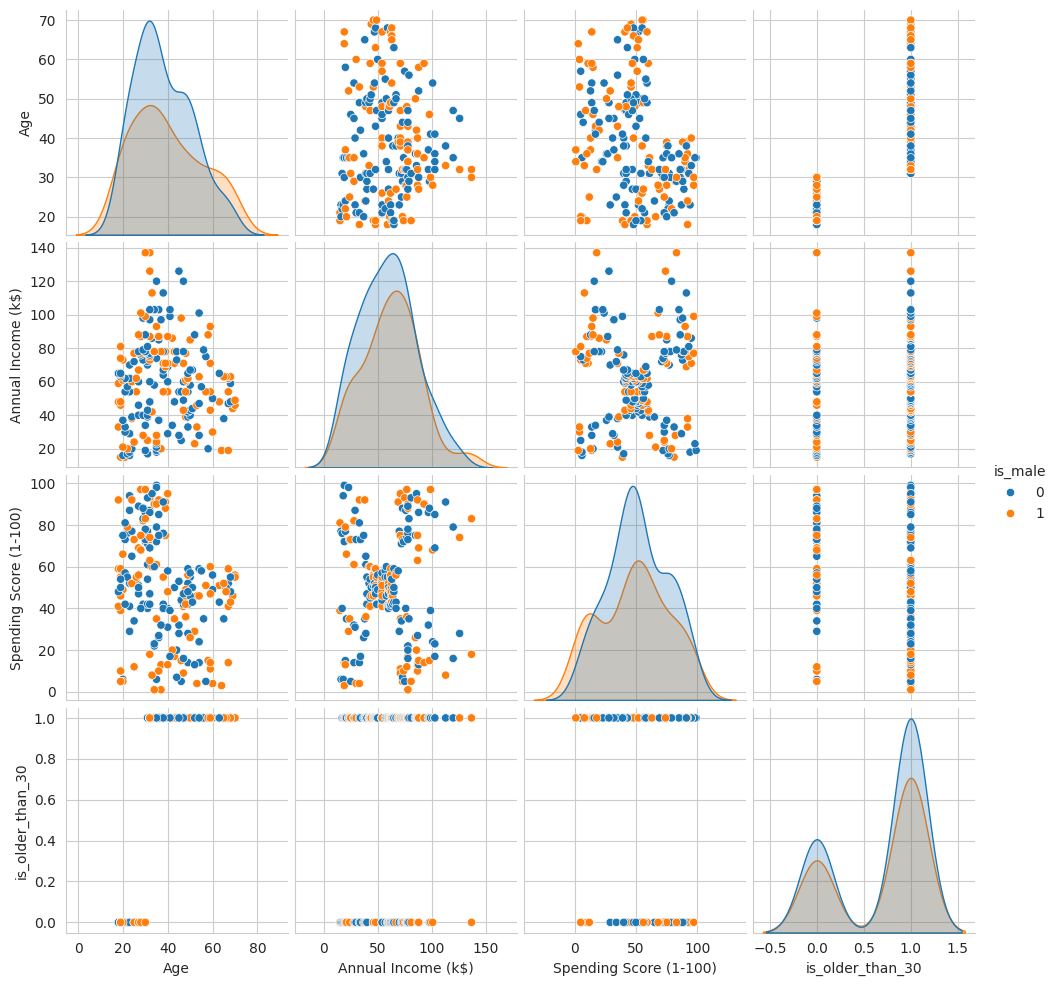

In [100]:
plt.figure(figsize=(12, 8))
sns.pairplot(
    df, 
    diag_kind='kde', 
    hue='is_male'
)

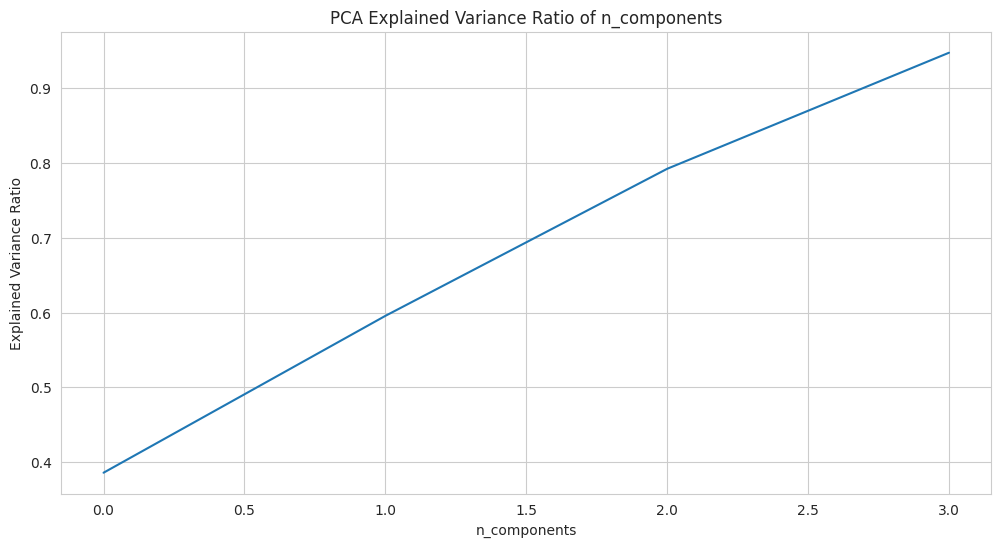

In [101]:
pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=4)
                   )

X_pca = pca.fit(df)

plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(X_pca[1].explained_variance_ratio_))
plt.title('PCA Explained Variance Ratio of n_components')
plt.xlabel('n_components')
plt.ylabel('Explained Variance Ratio')
plt.show()

In [102]:
pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=3)
)

pca.fit(df)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=3))])

Total Variance Explained: 79.23%


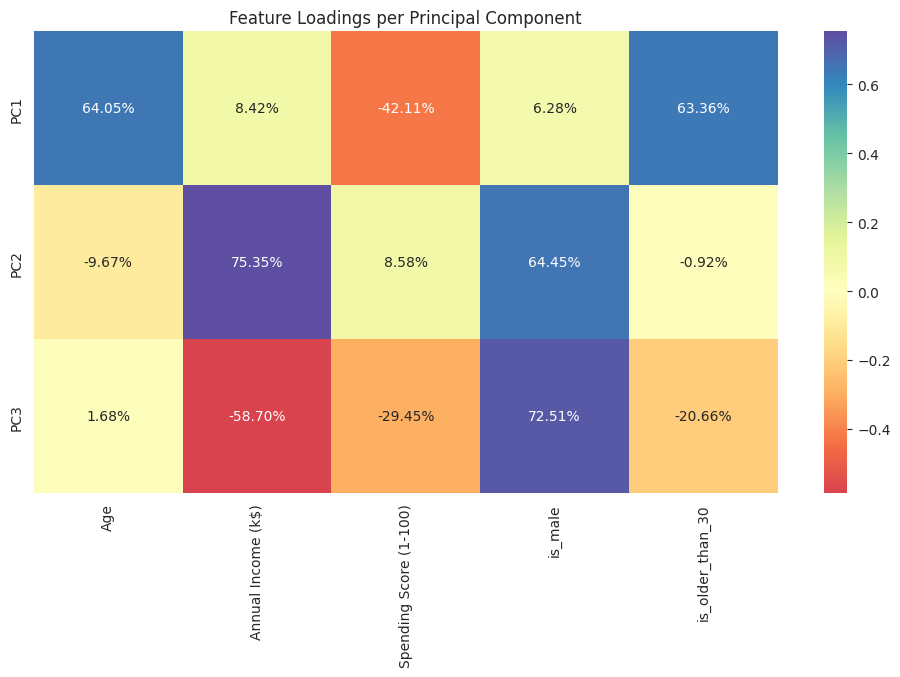

In [103]:
loadings_df = pd.DataFrame(
    pca[1].components_, 
    columns=df.columns, 
    index=['PC1', 'PC2', 'PC3']
)

explained_var = pca[1].explained_variance_ratio_
print(f"Total Variance Explained: {sum(explained_var):.2%}")

plt.figure(figsize=(12, 6))
sns.heatmap(loadings_df, annot=True, cmap='Spectral', center=0, fmt='.2%')
plt.title('Feature Loadings per Principal Component')
plt.show()

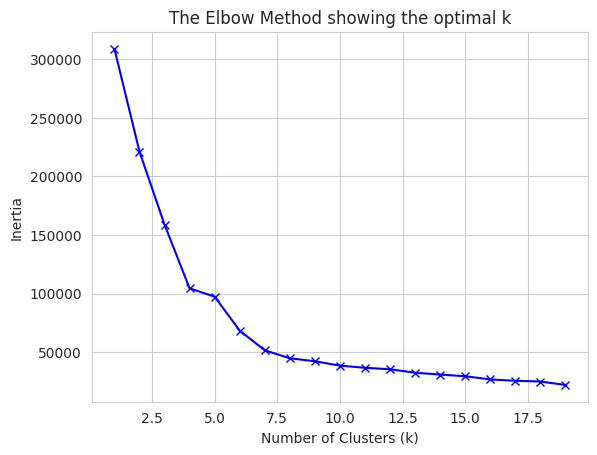

In [104]:
clusters = range(1, 20)
inertia = []

for k in clusters:
    KmeanModel = KMeans(n_clusters=k, n_init='auto', random_state=42)
    KmeanModel.fit(df)
    inertia.append(KmeanModel.inertia_)

plt.plot(clusters, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [105]:
kmeans = KMeans(n_clusters=6, n_init='auto')
labels = kmeans.fit_predict(df)

score = silhouette_score(df, labels)
print(f"Средний силуэт: {score:.3f}")

Средний силуэт: 0.451


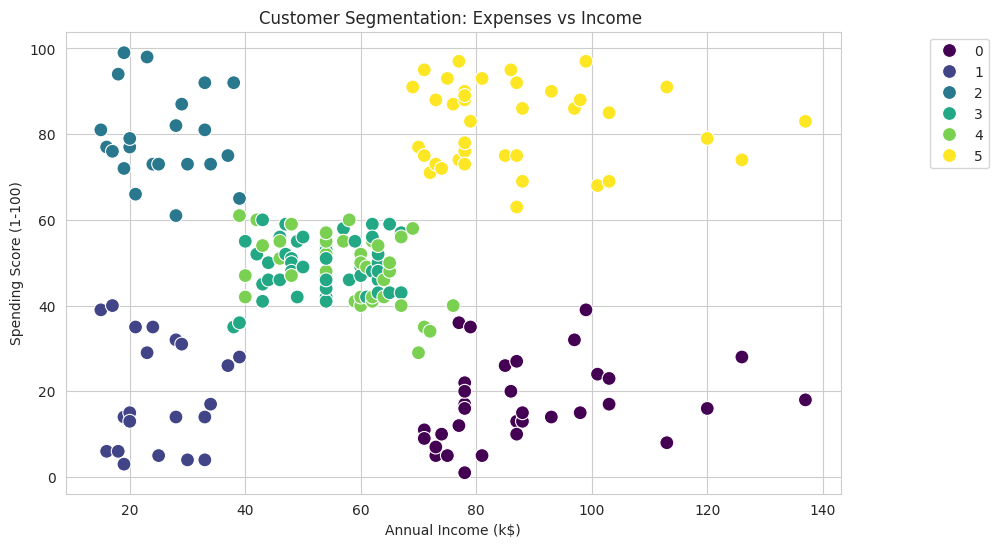

In [106]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue=kmeans.labels_, palette='viridis', s=100)
plt.title('Customer Segmentation: Expenses vs Income ')
plt.legend(bbox_to_anchor=(1.2, 1.), loc='upper right')
plt.show()

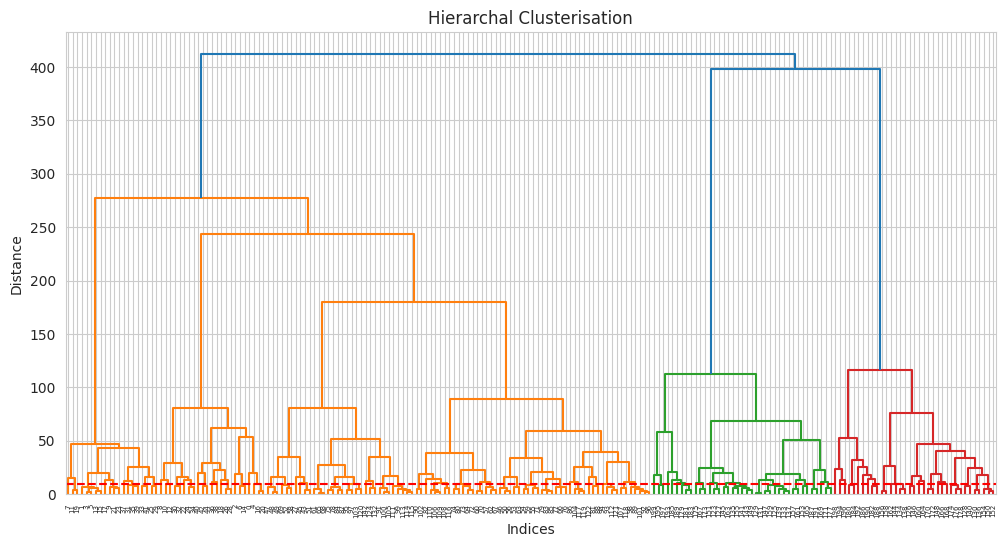

Принадлежность к кластерам: [24  3 22  3 23  3 21  2 11  4 10  1 10  3 21  3 23  5 20  1 23  4 14  4
 13  9 19 29 19  9 12  6 12  8 13  6 17  7 18  6 16  8 15 27 15 28 44 25
 25 25 44 27 26 45 46 46 44 43 26 46 42 30 43 45 41 30 48 43 30 26 42 46
 41 41 41 31 48 48 31 47 41 51 40 47 31 47 50 31 51 55 37 35 55 53 53 32
 55 32 55 36 35 55 37 32 49 35 38 54 39 38 38 36 53 36 36 36 39 49 54 49
 32 53 52 64 33 69 85 64 92 68 93 68 33 69 84 67 93 69 84 69 92 67 34 67
 84 66 85 69 90 67 94 65 94 71 94 67 83 70 83 69 86 70 84 66 87 71 89 62
 89 74 88 73 88 62 91 63 91 73 91 58 78 58 79 58 78 60 81 72 79 59 80 72
 82 61 75 56 76 56 77 57]


In [107]:
rng = np.random.default_rng(seed=1)

lk_ = linkage(df, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(lk_)
plt.title('Hierarchal Clusterisation')
plt.xlabel('Indices')
plt.ylabel('Distance')
plt.axhline(y=10, color='r', linestyle='--') # Линия разреза
plt.show()

clusters = fcluster(lk_, t=10, criterion='distance')
print(f"Принадлежность к кластерам: {clusters}")

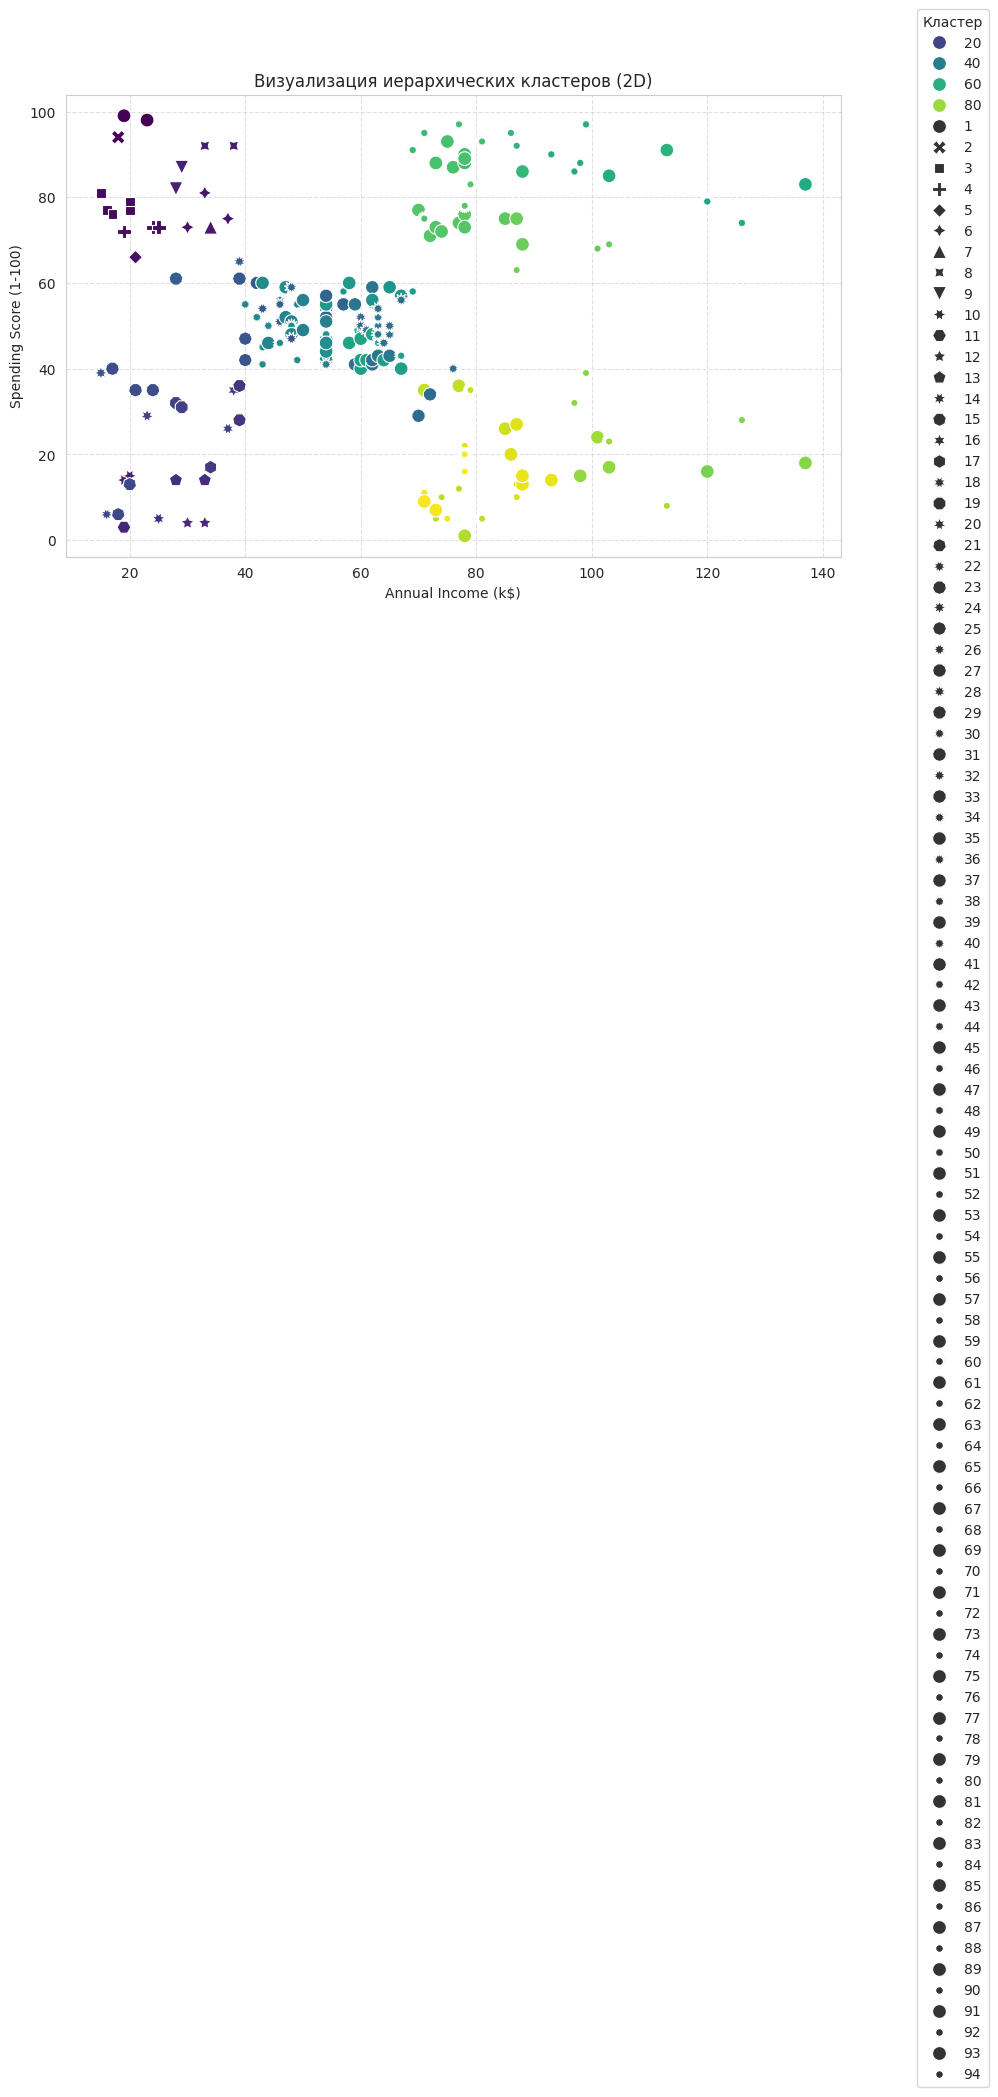

In [108]:
df['cluster_labels'] = clusters


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='cluster_labels', 
    palette='viridis', 
    s=100, 
    style='cluster_labels' # Разные формы точек для пущей ясности
)

plt.title('Визуализация иерархических кластеров (2D)')
plt.legend(title='Кластер', loc='upper right', bbox_to_anchor=(1.2, 1.2))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [109]:
# df['cluster_labels'].nunique()

94